In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

In [2]:
df = pd.read_csv('dataset/smartcart_customers.csv')

In [3]:
df.shape

(2240, 22)

In [11]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

In [12]:
# Fill missing values in the 'Income' column with the median income
df["Income"] = df["Income"].fillna(df["Income"].median())

In [13]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [14]:
# Feature Engineering
df["Age"] = 2026 - df["Year_Birth"]

In [15]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [16]:
# Total Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [17]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [18]:
# Education of Customers
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [19]:
# Combining Education Data
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [20]:
# Marital Status of Customers
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [21]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [22]:
# Dropping Unnecessary Columns
cols = ["ID", "Year_Birth", "Dt_Customer", "Kidhome", "Teenhome", "Marital_Status"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [23]:
df_cleaned.shape

(2240, 15)

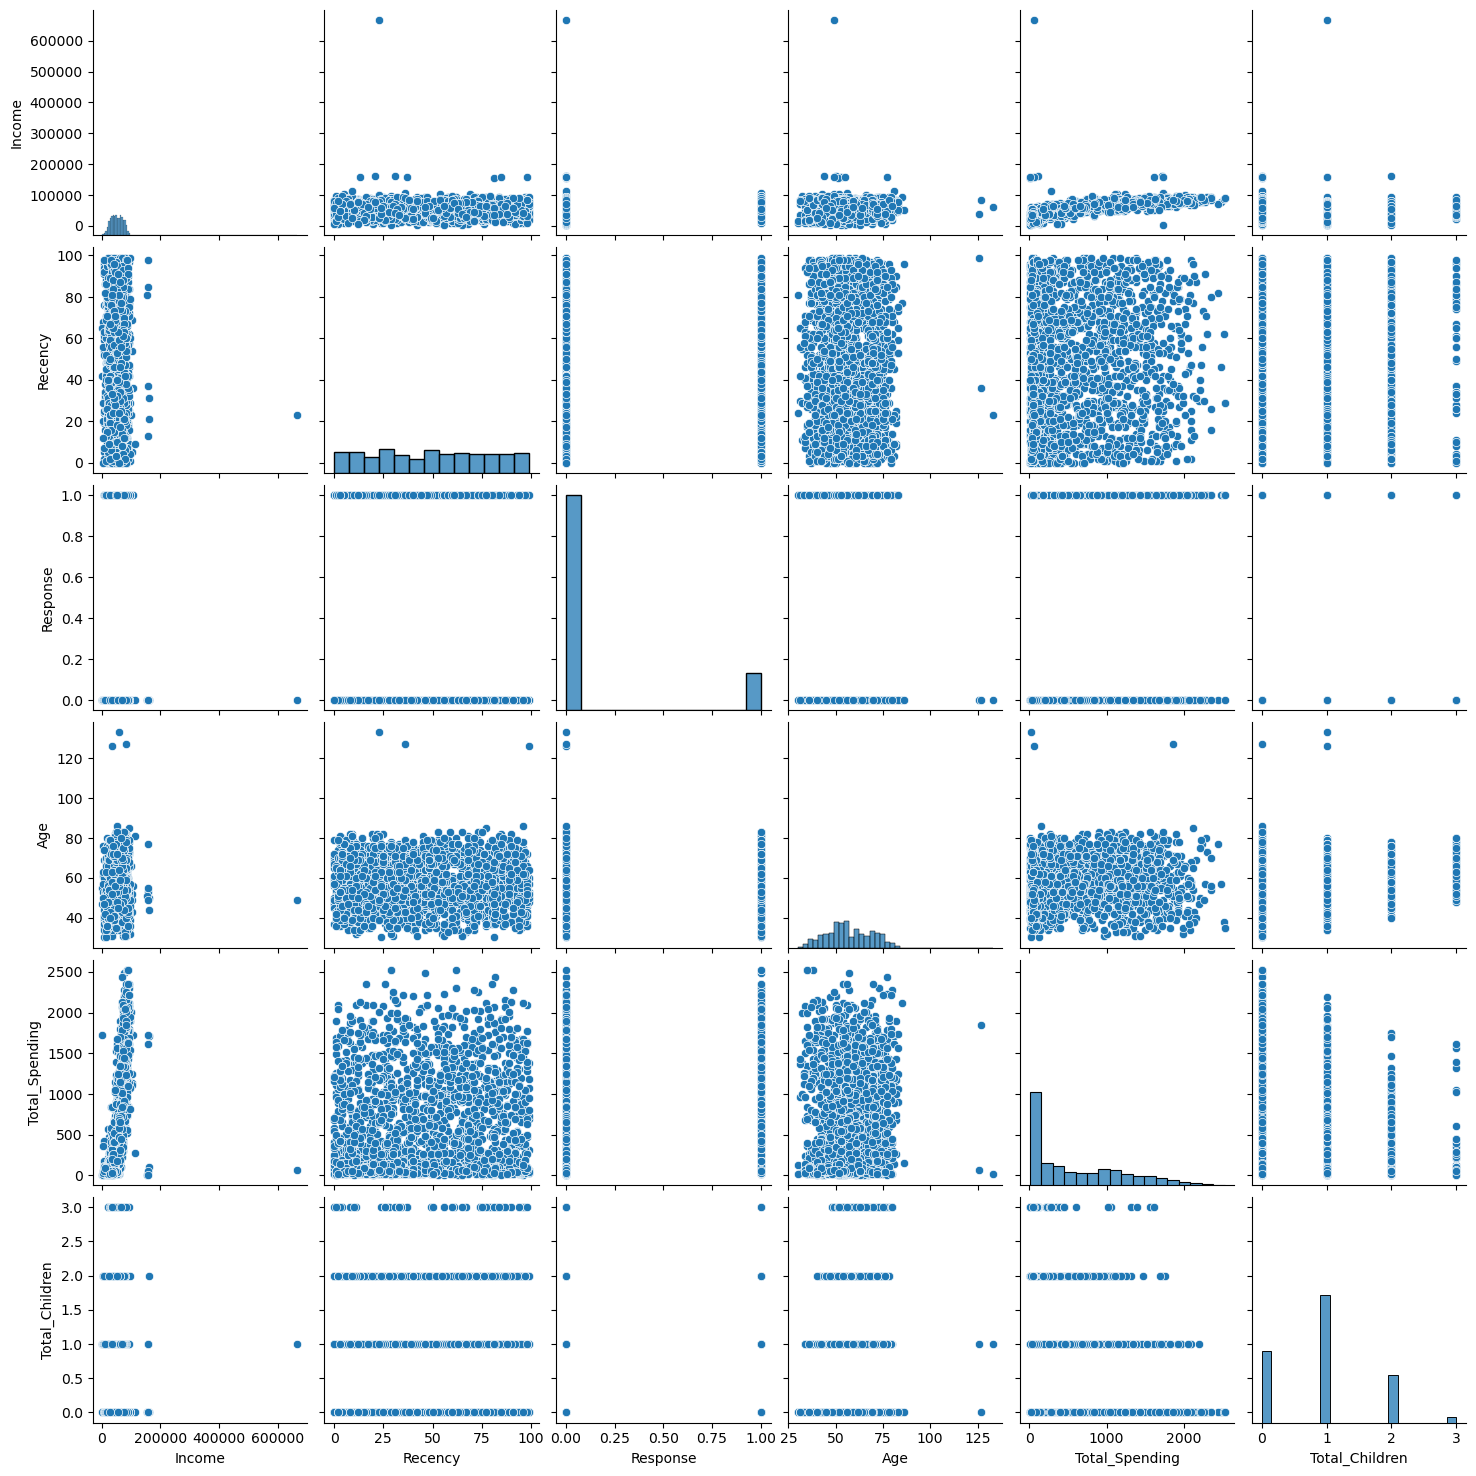

In [24]:
# Handling Outliers
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

sns.pairplot(df[cols])

In [25]:
# Removing Outliers
print("Data Size with Outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90 ) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000 ) ]

print("Data Size without Outliers:", len(df_cleaned))

Data Size with Outliers: 2240
Data Size without Outliers: 2236


### HeatMap - showing correlation between features

In [26]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

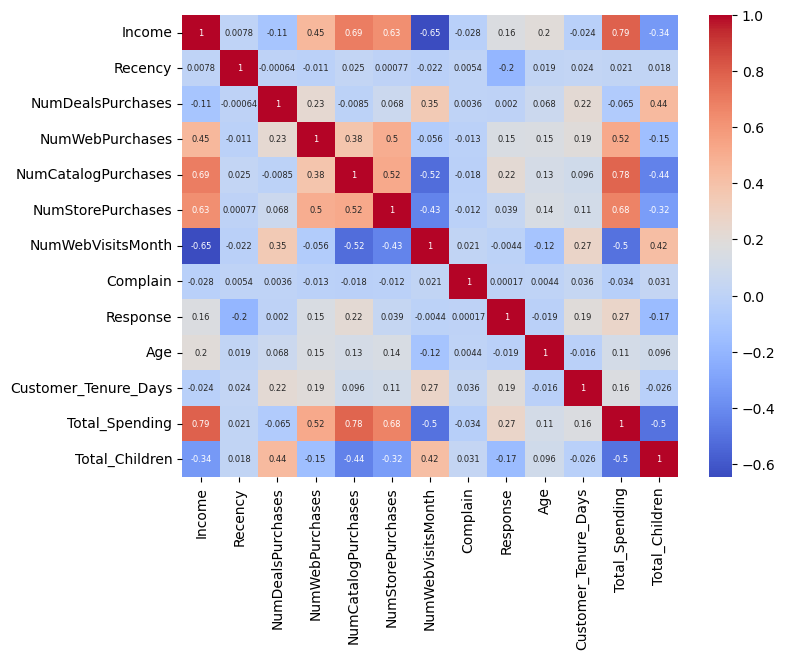

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm",
)

In [28]:
# Encoding
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [29]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [30]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [31]:
df_encoded.shape

(2236, 18)

In [32]:
# Standardize the data
X = df_encoded

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
# Dimensionality Reduction with PCA
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, 'PCA of Customer Data')

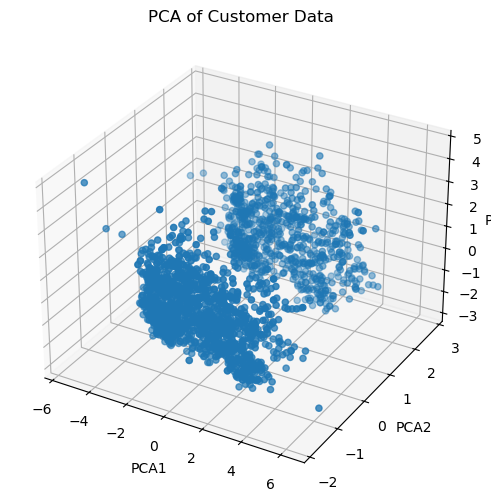

In [34]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('PCA of Customer Data')

### 1. Elbow Method

In [35]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)    

In [36]:
knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow

Optimal K value: 4


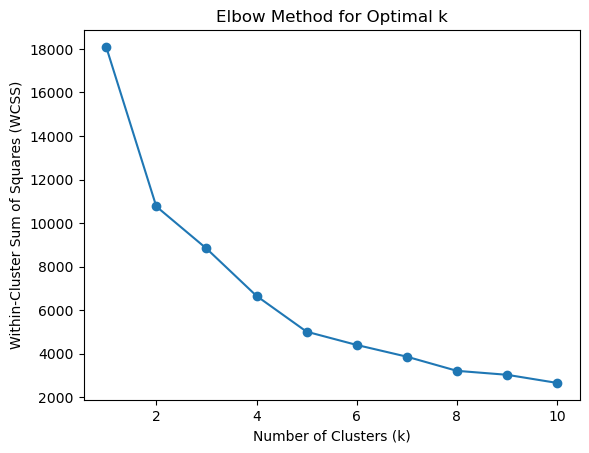

In [37]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')

print("Optimal K value:", optimal_k)

### 2. Silhouette Score

Text(0.5, 1.0, 'Silhouette Score for Different k Values')

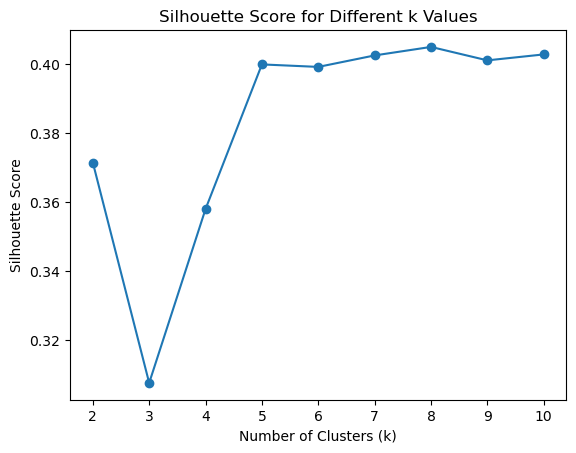

In [38]:
scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k Values')

Text(0, 0.5, 'Silhouette Score')

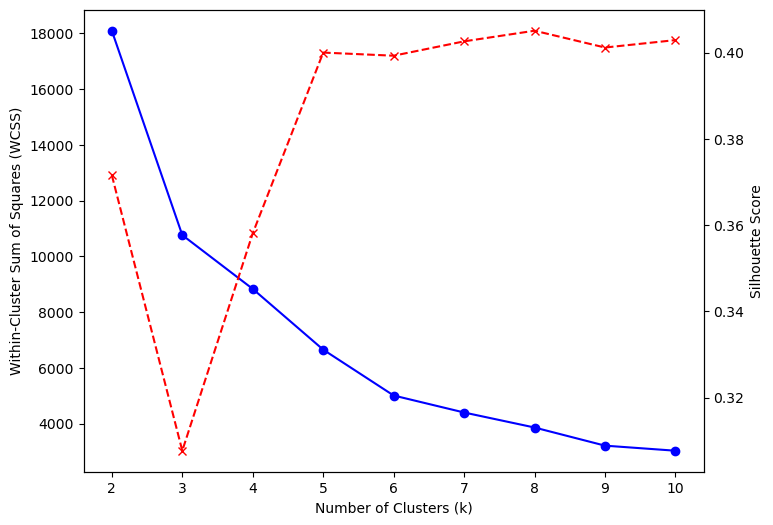

In [39]:
# Combined Plot - Elbow Method and Silhouette Score

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker='o', color='blue')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker='x', color='red', linestyle='--')
ax2.set_ylabel('Silhouette Score')

### Clustering

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

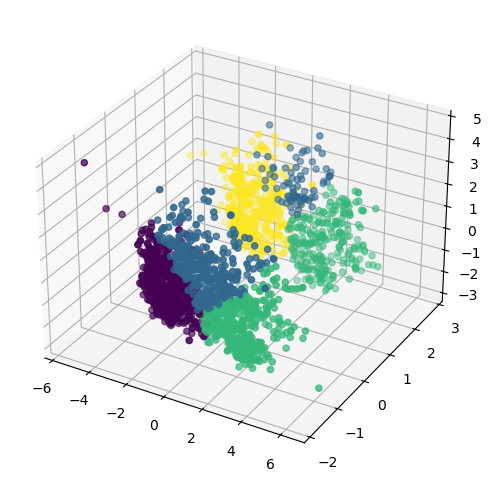

In [48]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

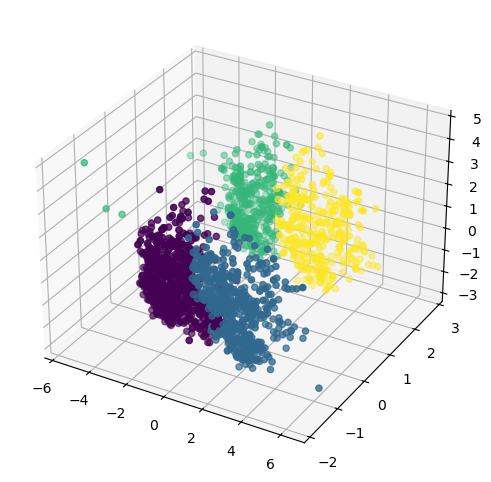

In [50]:
# Agglomerative Clustering
agg_clf = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

### Characterization of Clusters

In [51]:
X["cluster"] = labels_agg

<Axes: xlabel='cluster', ylabel='count'>

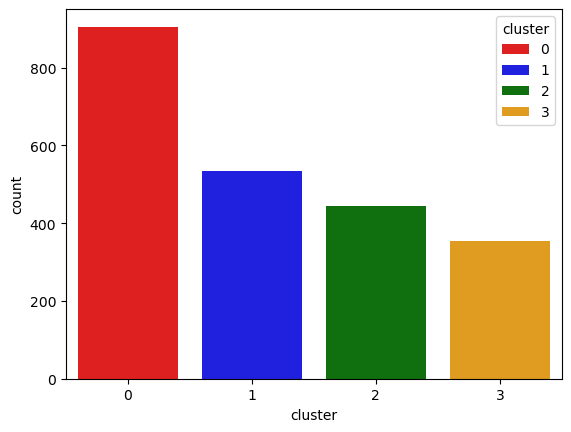

In [52]:
pal = ["red", "blue", "green", "orange"] # Color palette for clusters

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

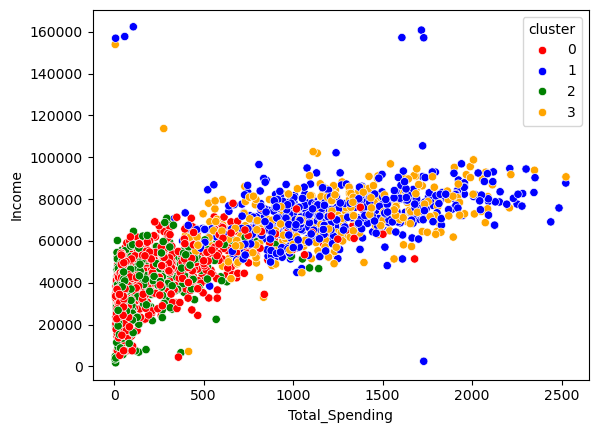

In [53]:
# Income & Spending Patterns
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [54]:
# Cluster Summary
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         